# Introducción al aprendizaje automatizado (O2026)

## Tutorial 2 unificado: Histogramas y Kernel Density

Este notebook unifica **la parte 1 (Histogramas y visualización)** y **la parte 2 (Kernels)**.

## Tutorial 2. (Parte 1) Histogramas y Visualización de datos

**Objetivo:**
Que se familiaricen con métodos no paramétricos para estimacion de la distribución de densidad de una variable aleatoria.

### Métodos no paramétricos
El objetivo es predecir distribución de una variable de interés 
- 𝑌 variable aleatoria de interés
- 𝑓(𝑌) distribución de densidad 𝑌

Métodos
- Repaso a Numpy vs. Pandas
- Histogramas con Matplotlib
- Histogramas mejorados con Seaborn y sus opciones


#### Repaso: NumPy y scikit-learn
**El paquete NumPy** es fundamental en Python. Está escrito en lenguajes de bajo nivel, lo que permite realizar operaciones matemáticas de manera muy eficiente. Para más información, ver la [guía oficial de uso de NumPy](https://docs.scipy.org/doc/numpy/user/index.html).

**El paquete scikit-learn** es una biblioteca de Python usada para machine learning, construida encima de NumPy y otros paquetes. Permite procesar datos, reducir la dimensionalidad de la base, implementar regresiones, clasificaciones, clustering y más. Pueden ver la [web de scikit-learn](https://scikit-learn.org/stable/)


In [122]:
# Installamos el paquete necesario
!pip install scikit-learn

# Alternativa
#import sys
#!{sys.executable} -m pip install scikit-learn

In [125]:
# Importamos paquetes
import numpy as np  #poder usar sus funciones en el notebook
import pandas as pd #para poder usar sus funciones en el notebook de leer datos tabulados.
import matplotlib.pyplot as plt #para graficar

#### Repaso breve de Numpy

A continuación crearemos dos vectores con los que trabajaremos en nuestra primera regresión lineal.

In [126]:
# Generamos datos aleatorios con distribución normal
np.random.seed(20) #random genera numeros aleatorios y seed fija la semilla aleatoria para que los resultados simulados sean reproducibles cada vez que se ejecute.
X = np.concatenate([np.random.normal(0, 1, 500), np.random.normal(5, 1, 500)]) # Genera datos simulados uniendo observaciones de dos distribuciones normales distintas en un solo arreglo.


##### Estastistica descriptiva en Numpy vs. Pandas

In [130]:
# Estadistica descriptiva en Numpy
print("Media", np.mean(X).round(2))
print("Desvío Estándar (s.d.)", np.std(X).round(2))
print("Mínimo", np.min(X).round(2))
print("Mediana", np.percentile(X,50).round(2))
print("Máximo", np.max(X).round(2))

Media 2.5
Desvío Estándar (s.d.) 2.67
Mínimo -3.19
Mediana 2.21
Máximo 7.89


In [134]:
# convertimos la matriz en un base de datos ("DataFrame")
df_X = pd.DataFrame(X,columns=['Var_Normal'])

# Visualizamos
print(df_X.head(3))

# Obtenemos estadistica descriptiva de las variables
df_X.describe().round(2)

   Var_Normal
0    0.883893
1    0.195865
2    0.357537


,Var_Normal
count,1000.00
mean,2.50
std,2.67
min,-3.19
25%,0.01
50%,2.21
75%,4.98
max,7.89


## Histogramas con Matplotlib
Como introducimos en clases anteriores, el módulo de Matplotlib nos ayuda a hacer gráficos y visualización de datos

Nuestro objetivo es estimar la distribucion de densidad $f(Y)$ una variable aleatoria Y, con la siguiente aproximación no parametrica:

$$
\hat{f}(y) = \frac{M}{n} ∑^𝑛_i I(𝑌_𝑖 \in B_l)  
$$
Con $B_l$ barra (bin) $l$-ésimo

Podemos usar el atributo `hist` de Matplotlib. Ver documentación [acá](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)

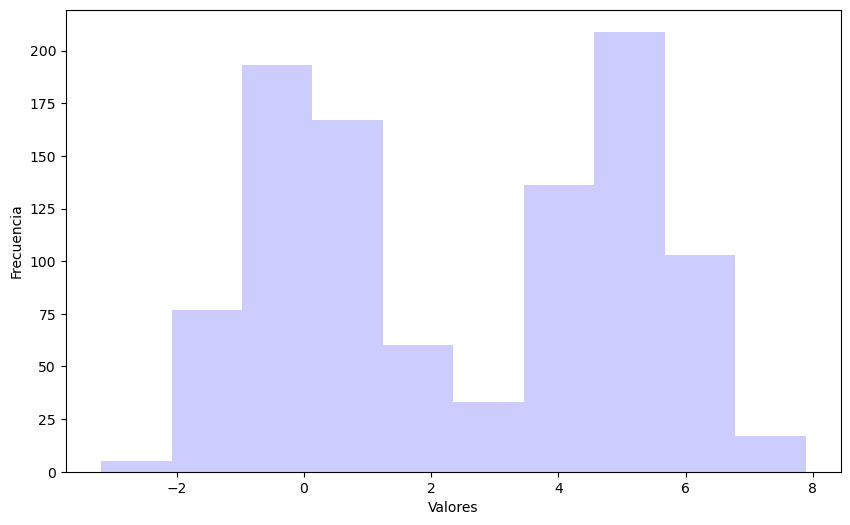

In [139]:
#Graficar
plt.figure(figsize=(10,6)) # Crea una nueva figura y define su tamaño para el gráfico que sigue.
plt.hist(X, alpha=0.2, color='blue') # por default, 10 bins. Crea una nueva figura y define su tamaño para el gráfico que sigue. alpha=transparencia
plt.xlabel('Valores') # etiqueta
plt.ylabel('Frecuencia') # etiqueta 
plt.show() # Muestra el gráfico construido hasta este punto.

A mayor número de barras (bins en ingles), menos observaciones se acumulan en cada bin (notar diferencia de escala en el eje y), como muestra el siguiente gráfico

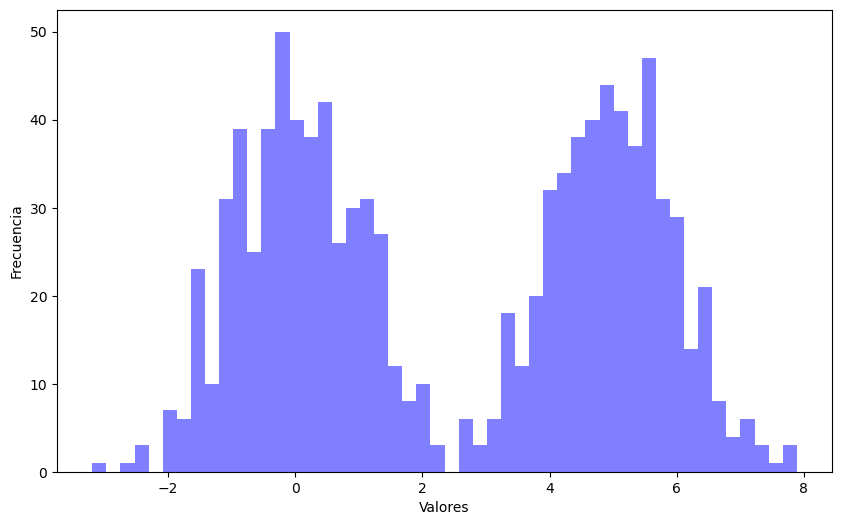

In [140]:
# Grafico
plt.figure(figsize=(10,6))
plt.hist(X, bins=50, alpha=0.5, color='blue', label='Histograma')
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.show()

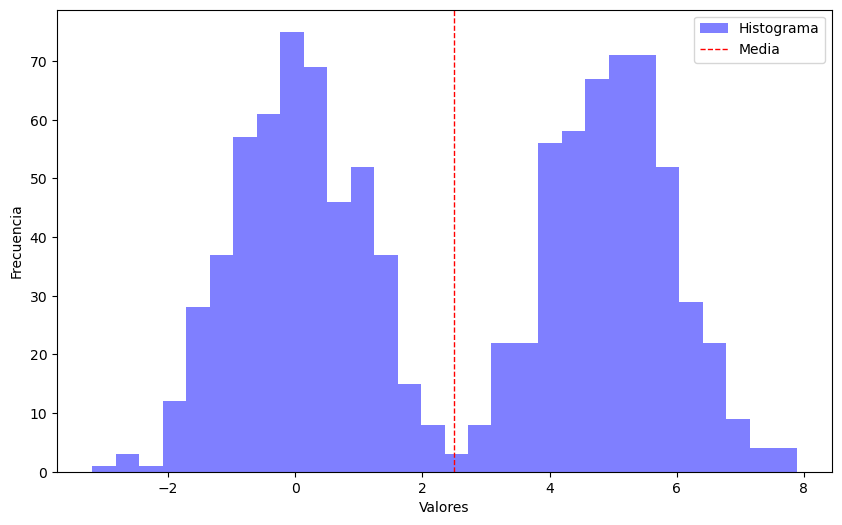

In [141]:
# Grafico
plt.figure(figsize=(10,6))
plt.hist(X, bins=30, alpha=0.5, color='blue', label='Histograma')
plt.xlabel('Valores')
plt.ylabel('Frecuencia')

# Agregamos línea vertical con la media
mean_value = np.mean(X)
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label='Media') # Agregamos línea vertical con la media
plt.legend()  
plt.show()

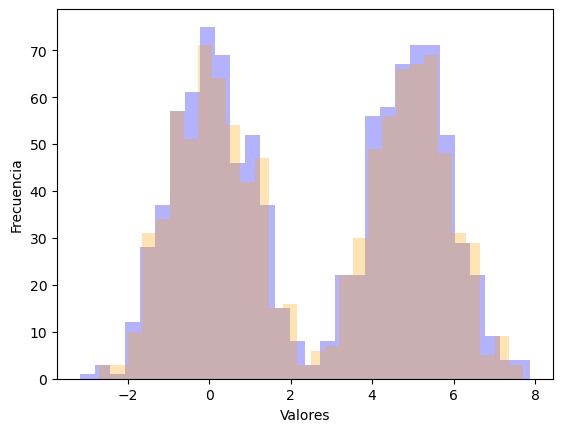

In [142]:
# Definimos un criterio para "cortar" outliers (por ejemplo, a 2 sd de la media)
mean_value = np.mean(X) # Calcula la media de la variable y la guarda en una nueva variable.
std_dev = np.std(X) #Calcula el desvío estándar y lo guarda para usarlo después.
lower_bound = mean_value - 2 * std_dev
upper_bound = mean_value + 2 * std_dev

# Filtramos los datos
X_filtered = X[(X >= lower_bound) & (X <= upper_bound)]

# Plot histogram of filtered data
plt.hist(X, bins=30, alpha=0.3, color='blue', label='Histograma')
plt.hist(X_filtered, bins=30, alpha=0.3, color='orange', label='Histograma')
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.show()

También podemos usar algunas funciones de seaborn para graficar histogramas. Ver documentación [acá](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot)


## Histogramas con Seaborn
En este ejemplop utilizaremos una base de datos del modulo de `seaborn`, también muy utilizada en procesamiento y visualización de datos en Python. Para más información ver [seaborn](https://seaborn.pydata.org/)

In [ ]:
# Primero, installamos el paquete
#!pip install seaborn

In [143]:
import seaborn as sns # Importa seaborn as sns para poder usar sus funciones en el notebook

In [144]:
tips = sns.load_dataset("tips") # Cargamos una base de ejemplo incluida en Seaborn para trabajar con datos reales.
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


##### Pregunta: Como verían la estadistica descriptiva de esta base de datos de propinas?

In [147]:
# resolver aquí


,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


#### Visualización de dos variables con Seaborn

Podemos hacer un lindo gráfico de dispersión entre dos variables rápidamente. Por ejemplo entre la cuenta total (`total_bill`) y las propinas (`tips`).

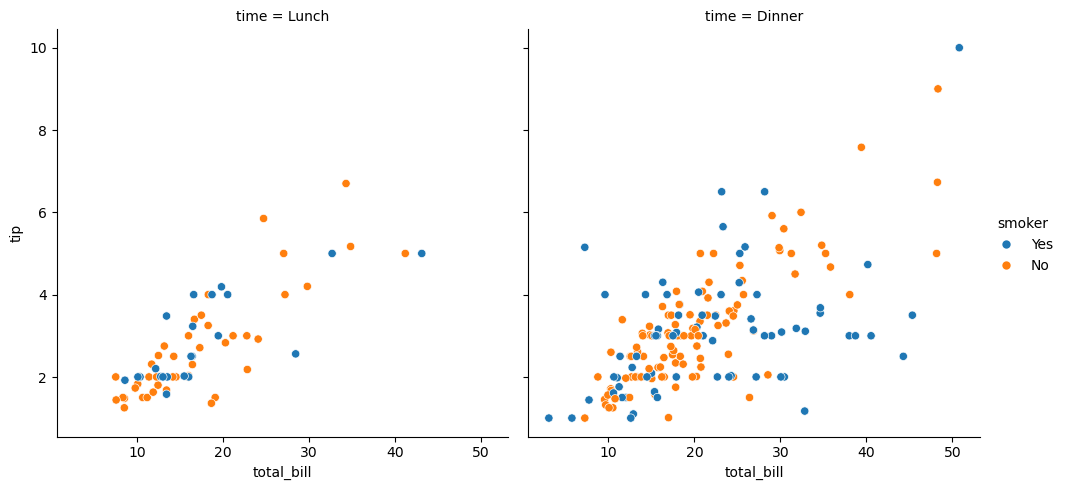

In [150]:
# Gráfico de dispersión

#sns.scatterplot(tips, x="total_bill", y="tip", color="red", s=50)


#sns.relplot(data=tips, x="total_bill", y="tip", color="red") # Crea un gráfico de dispersión para ver la relación entre dos variables.
sns.relplot(data=tips, x="total_bill", y="tip", col="time", hue="smoker") #quiero separarlos por tiempo y diferenciarlos por fumadores


Ahora sí, utilicemos seaborn para hacer un histogramas

Podemos alterar los ejes y opciones usando las opciones de **Matplotlib**

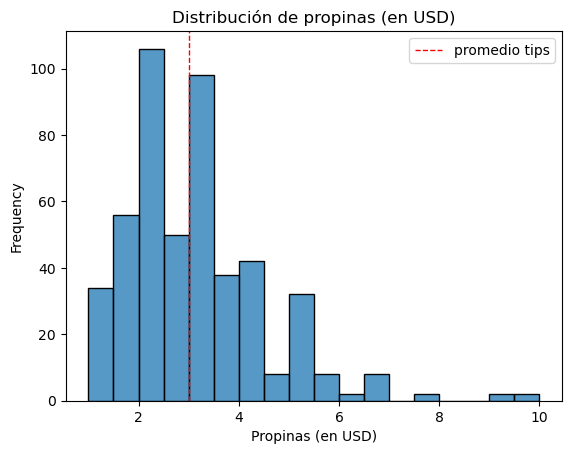

In [152]:
sns.histplot(data=tips['tip'], stat='density') # funcion de histograma de Seaborn

mean_tips = np.mean(tips['tip'])
plt.axvline(mean_tips, color='red', linestyle='dashed', linewidth=1,label='promedio tips') # Agrega una línea vertical al gráfico para marcar un valor de referencia.

plt.title("Distribución de propinas (en USD)")
plt.xlabel("Propinas (en USD)")
plt.legend()  # Nos muestra la leyenda para la media de tips

#### Histograma para dos categorías
Podemos hacer el histograma por grupos como varon y mujer, utilizando la opcion `hue`.

Text(0.5, 0, 'Propinas (en USD)')

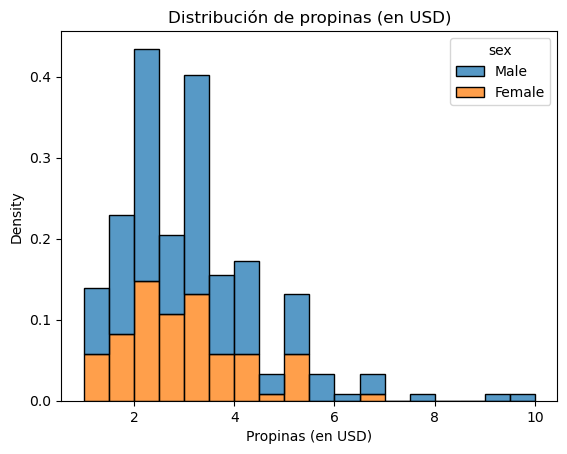

In [166]:
sns.histplot(data=tips, x="tip", stat='density', hue="sex", multiple="stack") #con multiple=stack estamos apilando la información; "dodge": lado a lado
#sns.histplot(data=tips, x="tip", hue="sex", multiple="layer")
plt.title("Distribución de propinas (en USD)")
plt.xlabel("Propinas (en USD)")

Tambien podemos hacerlo como dos paneles separados con la funcion `displot()` 

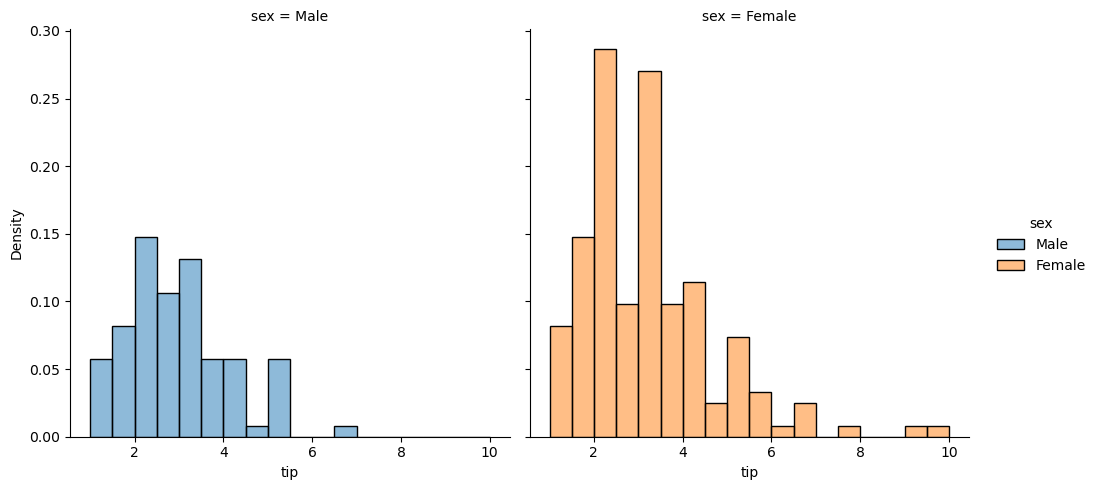

In [162]:
sns.displot(data=tips, x="tip", stat='density', hue="sex", col="sex") 
#hue: intenta diferenciar por sexo con colores dentro de un mismo gráfico
#col: separa en dos gráficos distintos, uno por sexo, dos paneles de columnas

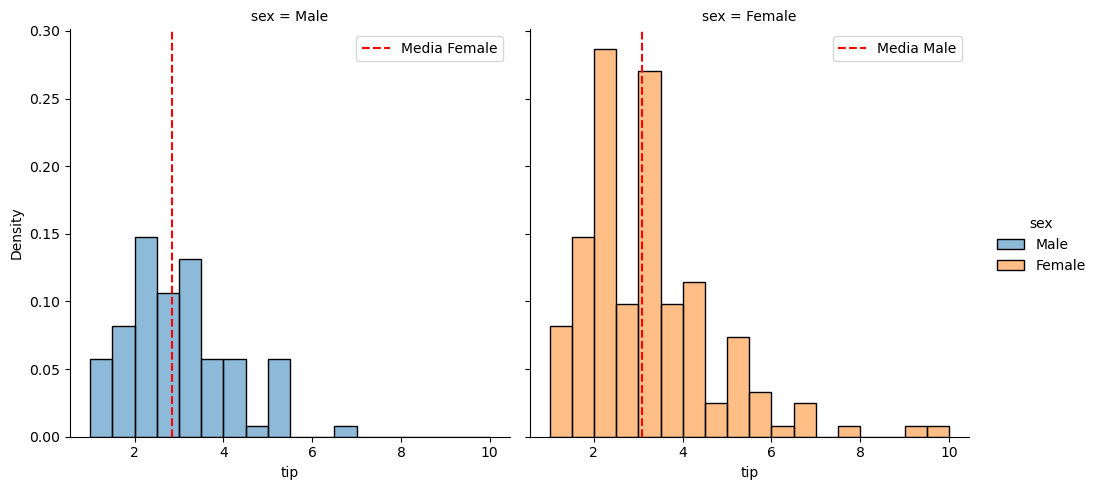

2

In [167]:
# Ahora le agregamos la media a cada distribución
g = sns.displot(data=tips, x="tip", stat='density', hue="sex", col="sex")  # Crea histogramas de la variable tip, separados en paneles según sex

for ax, sex in zip(g.axes[0], tips['sex'].unique()):  # Recorre simultáneamente cada panel del gráfico y cada categoría de sex
    media = tips[tips['sex'] == sex]['tip'].mean()  # Calcula la media de tip para el grupo correspondiente
    ax.axvline(media, color='r', linestyle='--', label=f'Media {sex}')  # Agrega una línea vertical roja punteada en la media de cada grupo
    ax.legend()  # Muestra la leyenda en cada panel

plt.show()  # Muestra el gráfico final

len(g.axes[0])

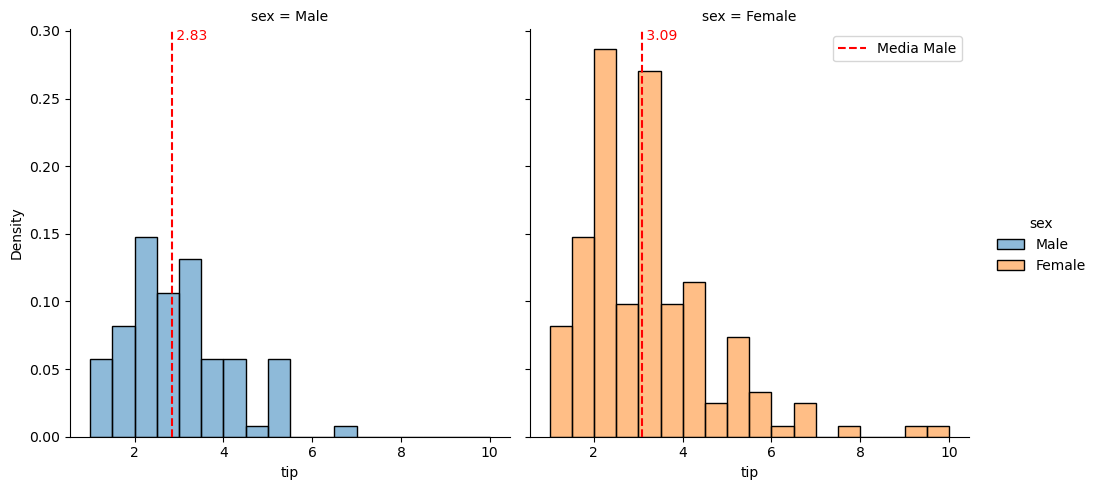

In [183]:
# Ahora le agregamos la media y el valor a cada distribución
g = sns.displot(data=tips, x="tip", stat='density', hue="sex", col="sex")  # Crea histogramas de tip, separados en paneles según sex

for ax, sex in zip(g.axes[0], tips['sex'].unique()):  # Recorre a la vez cada panel del gráfico y cada categoría de sex
    media = tips[tips['sex'] == sex]['tip'].mean()  # Calcula la media de tip para el grupo correspondiente
    ax.axvline(media, color='r', linestyle='--', label=f'Media {sex}')  # Agrega una línea vertical roja punteada en la media de cada grupo
    ax.text(media, ax.get_ylim()[1], f'{media: .2f}', ha='left', va='top', color='r')  # Escribe el valor numérico de la media arriba de la línea

g.axes[0][-1].legend()  # Muestra la leyenda en el último panel

plt.show()  # Muestra el gráfico final

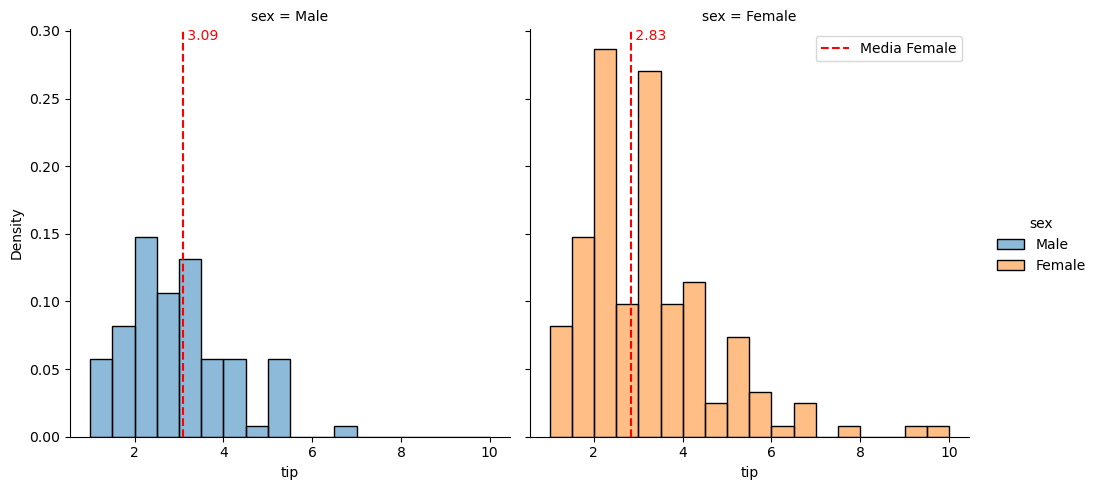

In [185]:
# Creamos los histogramas (uno por sexo)
g = sns.displot(
    data=tips,                # dataset
    x="tip",                  # variable a graficar
    stat='density',           # eje Y = densidad
    hue="sex",
    col="sex"                 # separa en paneles (Male / Female)
)

# Recorremos cada gráfico (ax) y cada categoría en el orden correcto
for ax, sex in zip(g.axes[0], g.col_names):
    # Filtramos los datos para ese sexo y calculamos la media
    media = tips[tips['sex'] == sex]['tip'].mean()
    
    # Dibujamos una línea vertical en la media
    ax.axvline(
        media, #objeto previo
        color='red', 
        linestyle='--', 
        label=f'Media {sex}'   #f es para que lo reconosca como string
    )
    
    # Escribimos el valor de la media arriba del gráfico
    ax.text(
        media,                      # posición en X (la media)
        ax.get_ylim()[1],           # parte superior del eje Y
        f'{media: .2f}',             # media con 2 decimales
        ha='left',                  # alineación horizontal
        va='top',                   # alineación vertical
        color='red'
    )

# Mostramos la leyenda solo en el último gráfico
g.axes[0][-1].legend()

plt.show()

### Opciones de distribución de la variable
En lugar es estimas la densidad $\hat{f}(y)$, podemos mostrar la cantidad de observaciones en cada barrita (en cada bin) como:
- `density`: La función de densidad esta *normalizada* para que el área total del histograma de 1 (esta es la que hicimos)
- `count`: cuenta el número de observaciones en cada barrita (bin)
- `frequency`: muestra el número de observaciones dividido el ancho de cada barrita (bin)
- `probability or proportion`: normalizada de modo tal que la suma de las alturas de 1.
- `percent`: normalizada de modo tal que la suma de las alturas de 100%


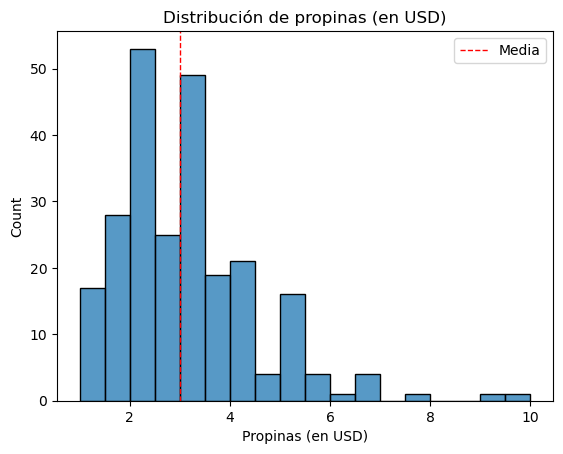

In [179]:
sns.histplot(data=tips, x='tip', stat='count')  # Hace el histograma de la variable tip, cantidad de casos
mean_tips = tips['tip'].mean()  # Calcula la media de tip
plt.axvline(mean_tips, color='red', linestyle='dashed', linewidth=1, label='Media')  # Agrega una línea vertical en la media
plt.title("Distribución de propinas (en USD)")  # Agrega el título del gráfico
plt.xlabel("Propinas (en USD)")  # Nombra el eje x
plt.legend()  # Muestra la leyenda

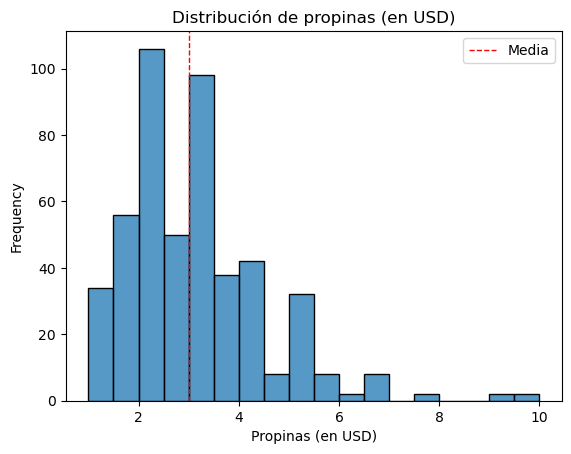

In [186]:
sns.histplot(data=tips, x='tip', stat='frequency')  # Hace el histograma de tip usando frecuencia, frecuencia ajustada por ancho del bin
mean_tips = tips['tip'].mean()  # Calcula la media de tip
plt.axvline(mean_tips, color='red', linestyle='dashed', linewidth=1, label='Media')  # Agrega una línea vertical en la media
plt.title("Distribución de propinas (en USD)")  # Agrega el título del gráfico
plt.xlabel("Propinas (en USD)")  # Nombra el eje x
plt.legend()  # Muestra la leyenda

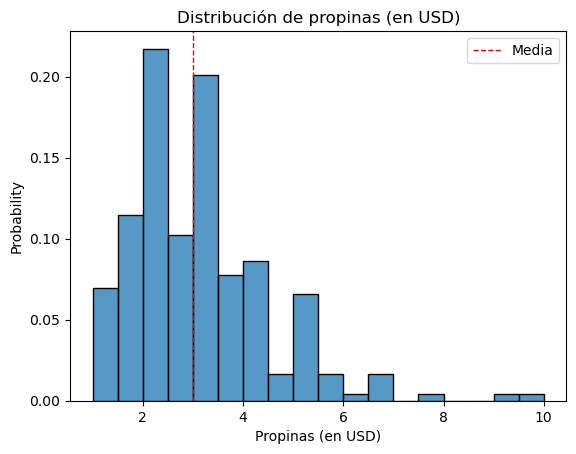

In [187]:
sns.histplot(data=tips, x='tip', stat='probability')  # Hace el histograma de tip mostrando probabilidades (suma total = 1) proporción del total
mean_tips = tips['tip'].mean()  # Calcula la media de tip
plt.axvline(mean_tips, color='red', linestyle='dashed', linewidth=1, label='Media')  # Agrega una línea vertical en la media
plt.title("Distribución de propinas (en USD)")  # Agrega el título del gráfico
plt.xlabel("Propinas (en USD)")  # Nombra el eje x
plt.legend()  # Muestra la leyenda

### Barritas (bins)
Ahora juguemos con las opciones del número de barritas (`bins`)

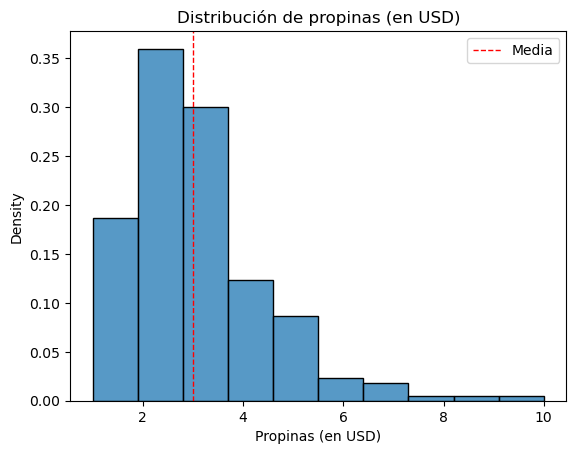

In [189]:
sns.histplot(data=tips, x='tip', stat='density', bins=10)  # Hace el histograma de tip con 10 bins
mean_tips = tips['tip'].mean()  # Calcula la media de tip
plt.axvline(mean_tips, color='red', linestyle='dashed', linewidth=1, label='Media')  # Agrega una línea vertical en la media
plt.title("Distribución de propinas (en USD)")  # Agrega el título del gráfico
plt.xlabel("Propinas (en USD)")  # Nombra el eje x
plt.legend()  # Muestra la leyenda

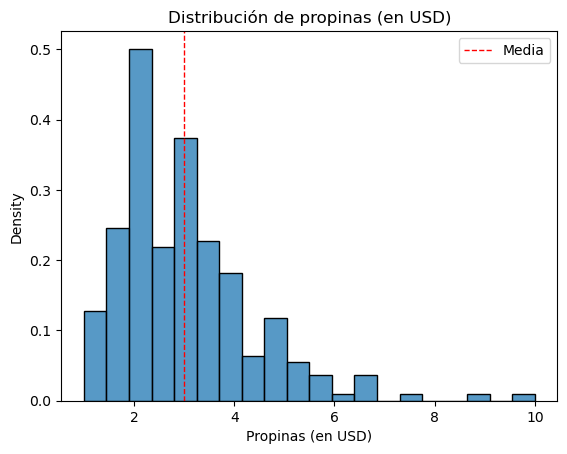

In [190]:
sns.histplot(data=tips, x='tip', stat='density', bins=20)  # Hace el histograma de tip con 20 bins
mean_tips = tips['tip'].mean()  # Calcula la media de tip
plt.axvline(mean_tips, color='red', linestyle='dashed', linewidth=1, label='Media')  # Agrega una línea vertical en la media
plt.title("Distribución de propinas (en USD)")  # Agrega el título del gráfico
plt.xlabel("Propinas (en USD)")  # Nombra el eje x
plt.legend()  # Muestra la leyenda

### Ancho de banda (binwidth)
Ahora juguemos con las opciones del ancho de banda (`binwidth`)

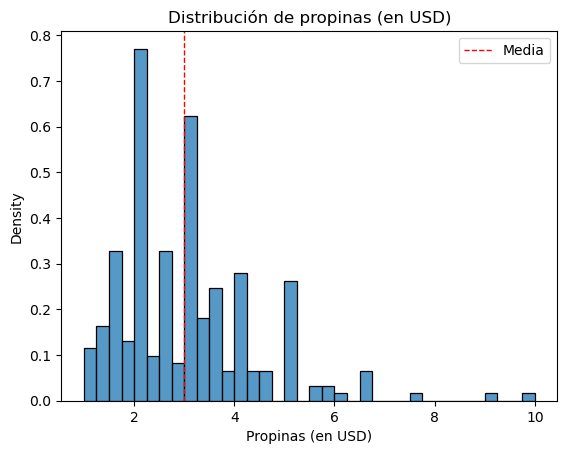

In [191]:
sns.histplot(data=tips, x='tip', stat='density', binwidth=0.25)  # Hace el histograma de tip con ancho de barra igual a 0.25
mean_tips = tips['tip'].mean()  # Calcula la media de tip
plt.axvline(mean_tips, color='red', linestyle='dashed', linewidth=1, label='Media')  # Agrega una línea vertical en la media
plt.title("Distribución de propinas (en USD)")  # Agrega el título del gráfico
plt.xlabel("Propinas (en USD)")  # Nombra el eje x
plt.legend()  # Muestra la leyenda

# Introducción al aprendizaje automatizado (O2026)

## Tutorial 2. (Parte 2) Kernels

**Objetivo:**
Que se familiaricen con el segundo método no paramétrico - Kernels - para la estimación de la distribución de densidad de una variable aleatoria.

In [ ]:
# Histograma con Seaborn para visualizar la distribución de la variable.

sns.histplot(data=tips, x="tip", hue="sex", stat="density", multiple="stack",  kde=True)

### Métodos no paramétricos
El objetivo es predecir distribución de una variable de interés 
- 𝑌 variable aleatoria de interés
- 𝑓(𝑌) distribución de densidad 𝑌

##### Métodos
- Kernels con Sckit-learn
    -  Tipo de funciones de kernels
    -  Opciones de Kernels: Ancho de banda $h$
    -  Simulación de datos: Sesgo de la estimación no parametrica de Kernels
- Kernels con Seaborn


In [ ]:
# Importamos paquetes
import numpy as np  # Para trabajar con arrays y generar datos
import pandas as pd  # Para manejar datos en formato tabla (DataFrame)
import matplotlib.pyplot as plt  # Para hacer gráficos
from scipy.stats import norm  # Para trabajar con distribuciones normales

import seaborn as sns  # Para hacer gráficos más avanzados y estéticos
from sklearn.neighbors import KernelDensity  # Para estimar densidades (KDE)

### Breve repaso de Histogramas


Estimamos la distribucion de densidad $f(Y)$ una variable aleatoria Y, con la siguiente aproximación no parametrica:

$$
\hat{f}(y) = \frac{M}{n} ∑^𝑛_i I(𝑌_𝑖 \in B_l)  
$$
Con $B_l$ barra (bin) $l$-ésimo

Podemos usar el atributo `hist` de Matplotlib. Ver documentación [acá](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)

In [ ]:
# Generamos datos
np.random.seed(20)  # Fija la semilla para que los resultados sean reproducibles
X = np.concatenate([np.random.normal(0,1,500), np.random.normal(5,1,500)]).reshape(-1,1)  # Genera datos uniendo dos normales y los pasa a formato columna
X  # Muestra los valores de X

In [ ]:
# Grafico
plt.figure(figsize=(10,6))  # Crea la figura y define el tamaño
plt.hist(X, bins=30, alpha=0.5, color='blue', label='Histograma')  # Hace el histograma de X
plt.xlabel('Valores')  # Nombra el eje x
plt.ylabel('Frecuencia')  # Nombra el eje y

# Agregamos línea vertical con la media
mean_value = np.mean(X)  # Calcula la media de X
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label='Media')  # Agrega una línea vertical en la media
plt.legend()  # Muestra la leyenda
plt.show()  # Muestra el gráfico

## Kernels

Kernel:
A cada observación le estima una pequeña función de densidad y suma todas las pequeñas funciones

$$
𝑓(𝑦_0)= \frac{1}{n} ∑^𝑛_i  \frac{1}{h} 𝐾(\frac{𝑌_𝑖−𝑦_0}{h}) 
$$

- $K(z)$  función Kernel continua (y generalmente) simétrica 
- $h$ ancho de banda (smoothing bandwidth) --> Controla qué tan “suave” es la densidad 


Vamos a usar el [módulo neighbors de Scikit learn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KernelDensity.html)

Para estimar una densidad usando kernels tenemos la siguiente función: 

<code> sklearn.neighbors.KernelDensity(*, bandwidth=1.0, algorithm='auto', kernel='gaussian', metric='euclidean', atol=0, rtol=0, breadth_first=True, leaf_size=40, metric_params=None)</code>

donde algunos parámetros importantes son:
- <code>bandwidth</code> (valor por default: 1.0)
- <code>kernel</code> (valor por default: 'gaussian')

Scikit learn nos permite cambiar el kernel y probar varios y cuál ajusta mejor a los datos

In [192]:
from sklearn.neighbors import KernelDensity

In [193]:
import numpy as np                     
import matplotlib.pyplot as plt        

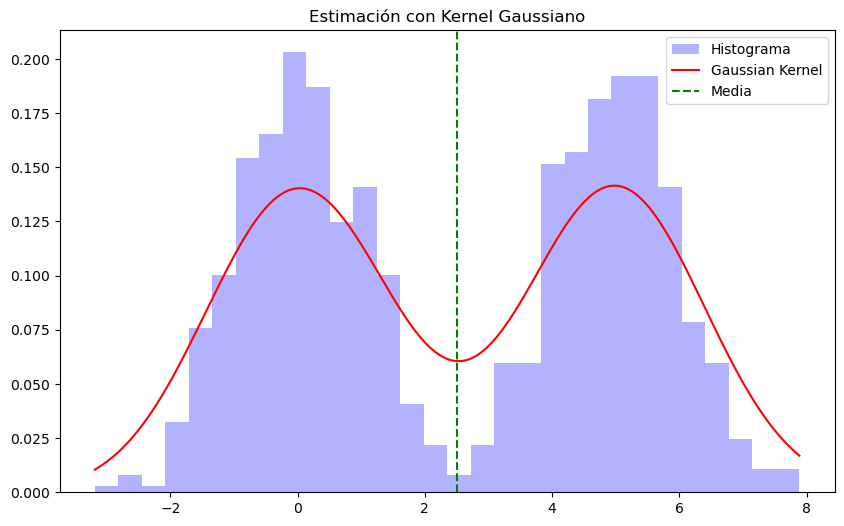

In [194]:
# Asegurar que X sea array
X = np.array(X)                         

# Crear grilla ANTES del reshape
X_plot = np.linspace(X.min(), X.max(), 1000).reshape(-1,1)  #-1 automaticam las filas, quiero 1 col
# Genera 1000 puntos entre el mínimo y el máximo de X; es donde evaluamos la densidad; reshape(-1,1) lo convierte en formato 2D (necesario para sklearn)

# Ahora sí reshape para KDE
X = X.reshape(-1, 1)                    # Convierte X en matriz columna (n observaciones, 1 variable)

# Grafico
plt.figure(figsize=(10,6))              # Crea una figura nueva de tamaño 10x6 

plt.hist(X, bins=30, density=True, alpha=0.3, color='blue', label='Histograma')  #bins=30: divide en 30 intervalos; density=True lo normaliza (área total = 1); alpha=0.3 transparencia

# KDE 
kde = KernelDensity().fit(X)  # Ajusta (aprende) la función de densidad usando los datos X

log_densities = kde.score_samples(X_plot)  # Evalúa la densidad en cada punto de la grilla PERO en logaritmo (por estabilidad numérica)

densities = np.exp(log_densities)  # Convierte de log-densidad a densidad normal (deshace el log)

plt.plot(X_plot[:,0], densities, color='red', label='Gaussian Kernel')   # Dibuja la curva KDE: # X_plot[:,0]: eje X (valores); densities: eje Y (densidad estimada)

# Media
mean_value = X.mean()                   

plt.axvline(mean_value, color='green', linestyle='dashed', label='Media')   # Dibuja una línea vertical en la media

plt.legend()                            # Muestra la leyenda (histograma, KDE, media)
plt.title('Estimación con Kernel Gaussiano')  # Título del gráfico
plt.show()                              # Muestra todo el gráfico

#### Tipos de kernels (disponibles en Scikit learn)

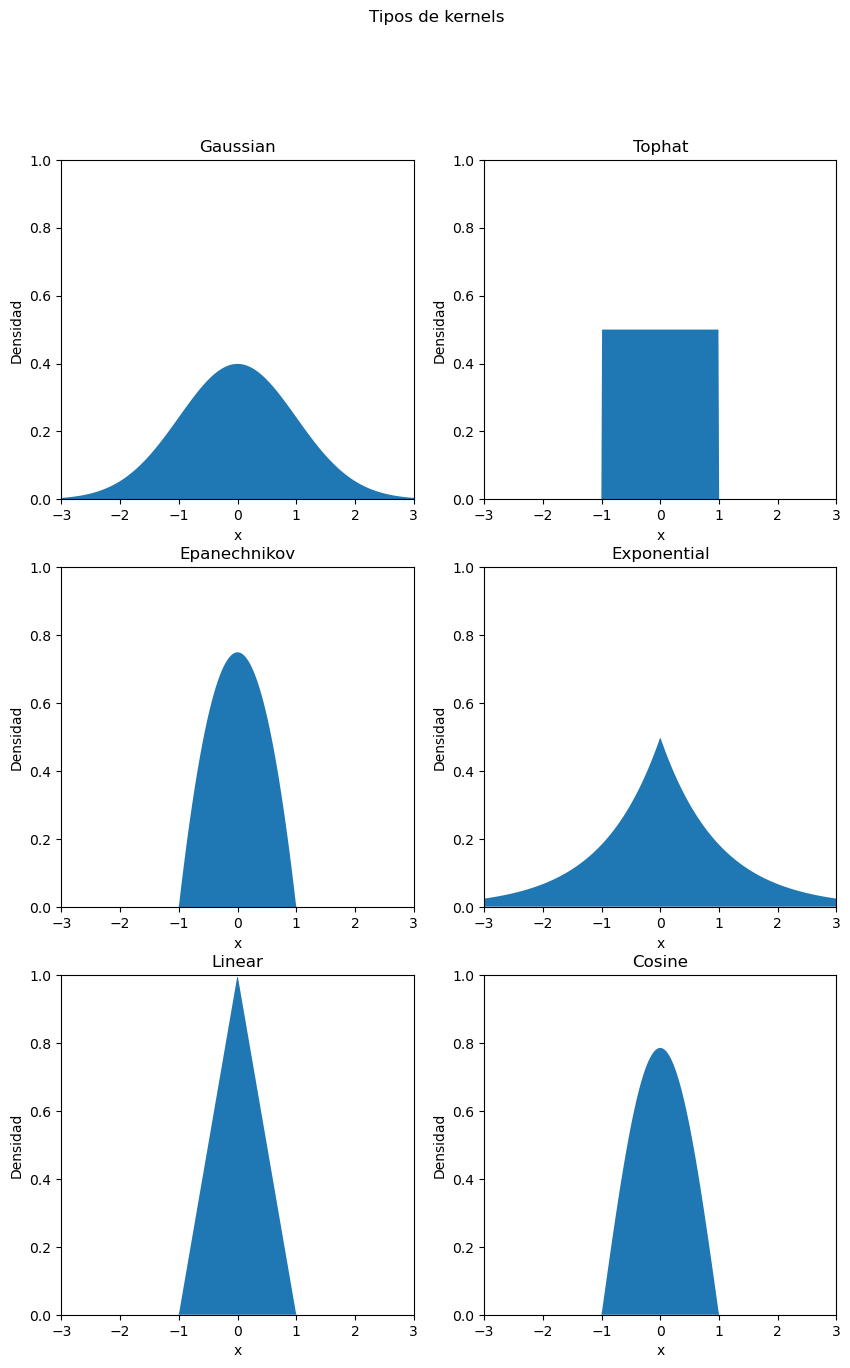

In [196]:
# Kernels a comparar
kernels = ["gaussian", "tophat", "epanechnikov", "exponential", "linear", "cosine"]  

# Creamos una figura con 3 filas y 2 columnas
fig, ax = plt.subplots(3, 2)
fig.set_figheight(15)  # Alto de la figura
fig.set_figwidth(10)  # Ancho de la figura
fig.suptitle("Tipos de kernels")  # Título general

# Generamos valores de x para graficar
x_plot = np.linspace(-6, 6, 1000).reshape(-1,1)  # Grilla de valores entre -6 y 6
x_orig = np.zeros((1, 1))  # Punto de referencia en 0

# Graficamos cada tipo de kernel
for i, kernel in enumerate(kernels):
    kde = KernelDensity(kernel=kernel).fit(x_orig)  # Ajusta el kernel usando el punto 0
    log_dens = kde.score_samples(x_plot)  # Calcula la log-densidad
    
    ax[i // 2, i % 2].fill(x_plot[:, 0], np.exp(log_dens))  # Dibuja la densidad del kernel
    ax[i // 2, i % 2].set_title(kernel.capitalize())  # Título de cada subplot
    ax[i // 2, i % 2].set_xlim(-3, 3)  # Rango del eje x
    ax[i // 2, i % 2].set_ylim(0, 1)  # Rango del eje y
    ax[i // 2, i % 2].set_ylabel("Densidad")  # Nombre del eje y
    ax[i // 2, i % 2].set_xlabel("x")  # Nombre del eje x

plt.show()  # Muestra la figura final

De la misma forma, en un gráfico

In [ ]:
# Kernels a comparar
kernels = ["gaussian", "tophat", "epanechnikov", "exponential", "linear", "cosine"]  
  
# Creamos el gráfico
plt.figure(figsize=(10,6))  # Crea la figura y define el tamaño

# Graficamos la estimación para cada kernel
for k in kernels:
    kde = KernelDensity(kernel=k).fit(x_orig)  # Ajusta el modelo usando el kernel elegido
    log_dens = kde.score_samples(x_plot)  # Calcula la log-densidad sobre la grilla de valores
    plt.plot(x_plot[:,0], np.exp(log_dens), label=f'{k.capitalize()} Kernel')  # Dibuja la curva de densidad para cada kernel

plt.legend()  # Muestra la leyenda
plt.title('Estimación con diferentes Kernels')  # Agrega el título del gráfico
plt.show()  # Muestra el gráfico final

Continuamos con el ejemplo de la variable X creada (en la clase pasada) probando los distintos tipos de kernels

Text(0.5, 1.0, 'Estimación con diferentes Kernels')

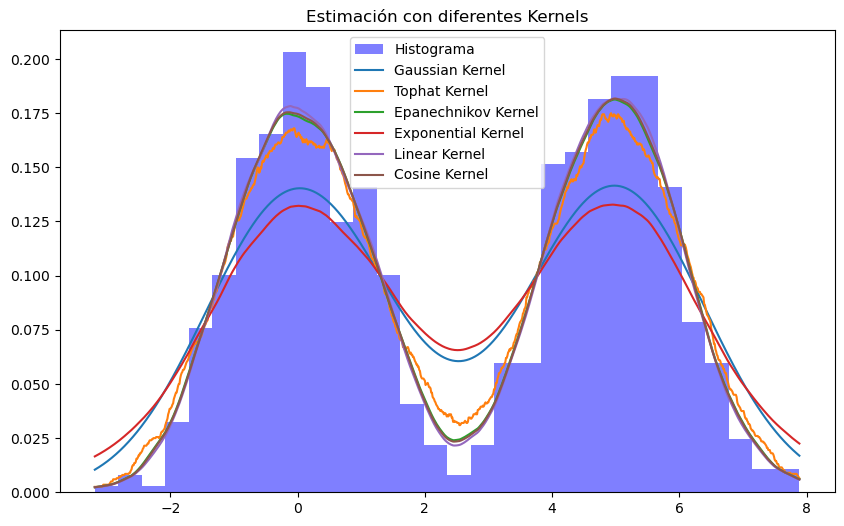

In [197]:
# Lista de kernels a probar
kernels = ["gaussian", "tophat", "epanechnikov", "exponential", "linear", "cosine"]  

# Grafico
plt.figure(figsize=(10,6))  # Crea la figura y define el tamaño
plt.hist(X, bins=30, density=True, alpha=0.5, color='blue', label='Histograma')  # Hace el histograma de X en densidad

# Graficamos la estimación con cada kernel
for k in kernels:
    kde = KernelDensity(kernel=k).fit(X)  # Ajusta la estimación de densidad con el kernel elegido
    
    log_densities = kde.score_samples(X_plot)  # Calcula la log-densidad en cada punto de la grilla
    densities = np.exp(log_densities)  # Convierte la log-densidad en densidad
    
    plt.plot(X_plot[:,0], densities, label=f'{k.capitalize()} Kernel')  # Dibuja la curva de densidad para cada kernel

plt.legend()  # Muestra la leyenda
plt.title('Estimación con diferentes Kernels')  # Agrega el título del gráfico

#### Opciones de Kernels: Ancho de banda $h$
Ahora veamos qué ocurre si para un mismo kernel, cambiamos los **anchos de banda**

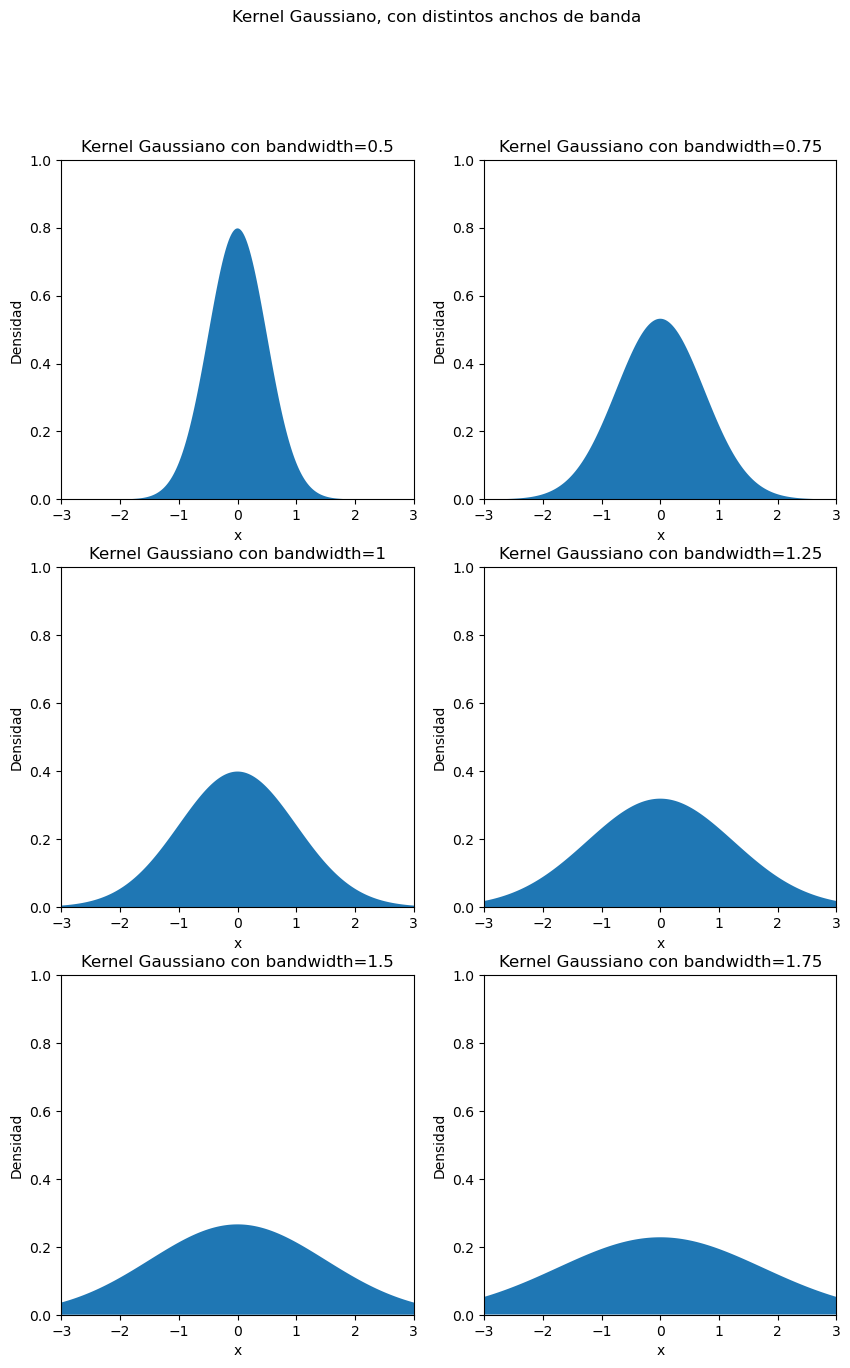

In [200]:
# Anchos de banda a comparar
bandwidths = [0.5, 0.75, 1, 1.25, 1.5, 1.75]  # Define los bandwidths que se van a comparar
  
# Creamos una figura con 3 filas y 2 columnas
fig, ax = plt.subplots(3, 2)
fig.set_figheight(15)  # Alto de la figura
fig.set_figwidth(10)  # Ancho de la figura
fig.suptitle('Kernel Gaussiano, con distintos anchos de banda')  # Título general

# Graficamos la densidad para cada bandwidth
for i, bw in enumerate(bandwidths):
    kde = KernelDensity(kernel='gaussian', bandwidth=bw).fit(x_orig)  # Ajusta el kernel gaussiano con el bandwidth elegido
    log_dens = kde.score_samples(x_plot)  
    
    ax[i // 2, i % 2].fill(x_plot[:, 0], np.exp(log_dens))  # Dibuja la densidad estimada
    ax[i // 2, i % 2].set_title('Kernel Gaussiano con bandwidth=' + str(bw))  # Título de cada subplot
    ax[i // 2, i % 2].set_xlim(-3, 3)  # Rango del eje x
    ax[i // 2, i % 2].set_ylim(0, 1)  # Rango del eje y
    ax[i // 2, i % 2].set_ylabel('Densidad')  # Nombre del eje y
    ax[i // 2, i % 2].set_xlabel('x')  # Nombre del eje x

plt.show()  

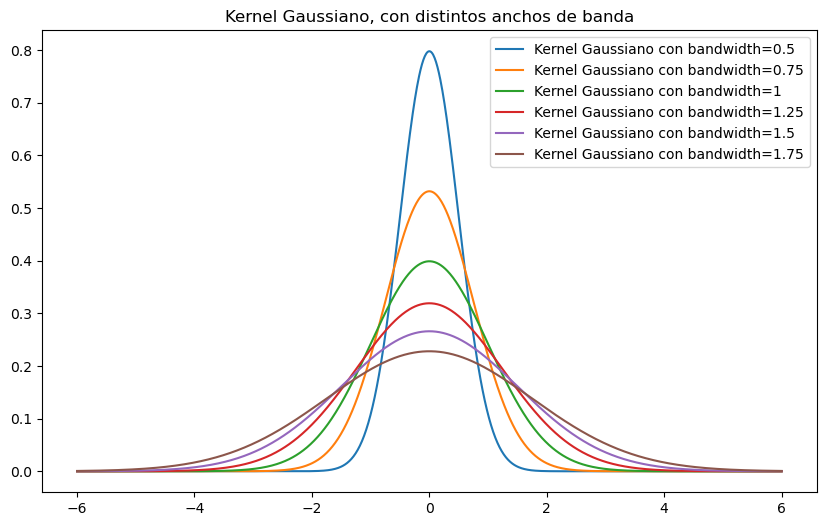

In [201]:
# Anchos de banda a comparar
bandwidths = [0.5, 0.75, 1, 1.25, 1.5, 1.75]  
  
# Creamos el gráfico
plt.figure(figsize=(10,6))  # Crea la figura y define el tamaño

# Graficamos la estimación para cada bandwidth
for bw in bandwidths:
    kde = KernelDensity(kernel='gaussian', bandwidth=bw).fit(x_orig)  # Ajusta el kernel gaussiano con el bandwidth elegido
    log_dens = kde.score_samples(x_plot)  # Calcula la log-densidad sobre la grilla
    plt.plot(x_plot[:,0], np.exp(log_dens), label='Kernel Gaussiano con bandwidth=' + str(bw))  # Dibuja la curva para cada bandwidth

plt.legend()  # Muestra la leyenda
plt.title('Kernel Gaussiano, con distintos anchos de banda')  # Agrega el título del gráfico
plt.show()  # Muestra el gráfico final

Text(0.5, 1.0, 'Estimación de Kernel Gaussiano con diferentes ancho de banda')

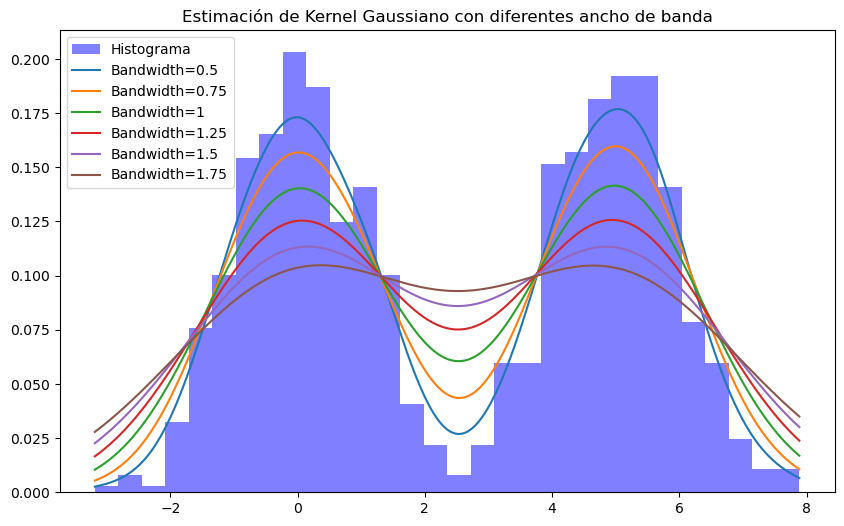

In [202]:
# Anchos de banda a comparar
bandwidths = [0.5, 0.75, 1, 1.25, 1.5, 1.75]  # Define los bandwidths que se van a comparar

# Grafico
plt.figure(figsize=(10,6))  # Crea la figura y define el tamaño
plt.hist(X, bins=30, density=True, alpha=0.5, color='blue', label='Histograma')  # Hace el histograma de X en densidad

# Graficamos la estimación para cada bandwidth
for bw in bandwidths:
    kde = KernelDensity(kernel='gaussian', bandwidth=bw).fit(X)  # Ajusta el kernel gaussiano con el bandwidth elegido a cada dato
    
    log_densities = kde.score_samples(X_plot)  # Calcula la log-densidad en cada punto de la grilla
    densities = np.exp(log_densities)  # Convierte la log-densidad en densidad
    
    plt.plot(X_plot[:,0], densities, label='Bandwidth=' + str(bw))  # Dibuja la curva para cada bandwidth

plt.legend()  # Muestra la leyenda
plt.title('Estimación de Kernel Gaussiano con diferentes ancho de banda')  # Agrega el título del gráfico

### Simulación de datos: Sesgo de la estimación no parametrica de Kernels
Ahora veamos un ejemplo donde creamos datos ficticios, esto implica que conocemos la verdadera forma en la que se generan los datos, para comparar la estimación no paramétrica de Kernels y su aproximación a la verdadera función de densidad. Se puede demostrar formalmente, que la estimación no paramétrica de Kernels (e histograma) es *sesgada*. Por lo que, aquí estamos ilustrando ese concepto.

In [2]:
from scipy.stats import norm

In [1]:
# Creamos una distribución
n = 100  # Define el tamaño total de la muestra
np.random.seed(10)  # Fija la semilla para que los resultados sean reproducibles
X = np.concatenate((np.random.normal(0, 1, int(0.6 * n)), np.random.normal(10, 1, int(0.4 * n))))  # Une datos de dos distribuciones normales
X = X.reshape(-1,1)  # Pasa X a formato columna

# Generamos una grilla de valores para graficar
X_plot = np.linspace(-5, 15, 1000).reshape(-1,1)  # 1000 puntos entre -5 y 15

# Calculamos la verdadera densidad teórica
true_density = 0.6 * norm(0, 1).pdf(X_plot[:, 0]) + 0.4 * norm(10, 1).pdf(X_plot[:, 0])  
  
# Gráfico
fig, ax = plt.subplots()  # Crea la figura 
  
# Graficamos la verdadera densidad
ax.fill(
    X_plot[:, 0], true_density,
    fc='black', alpha=0.2,
    label='Verdadera Distribución'
)  # Rellena el área bajo la densidad verdadera
  
# Estimamos la densidad con kernel gaussiano
kde = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(X)  # Ajusta la estimación de densidad
log_dens = kde.score_samples(X_plot)  # Calcula la log-densidad sobre la grilla
  
# Graficamos la densidad estimada
ax.plot(
    X_plot[:, 0], np.exp(log_dens),
    color='blue',
    linestyle='-',
    label='Densidad con kernel Gaussiano'
)  # Dibuja la densidad estimada

ax.set_xlim(-4, 15)  # Define el rango del eje x
ax.set_ylim(0, 0.3)  # Define el rango del eje y
#ax.grid(True)  # Agrega una grilla si se quiere mostrar
ax.legend(loc='upper right')  # Muestra la leyenda
plt.title('Sesgo de la estimación por Kernel')  # Agrega el título

plt.show()  # Muestra el gráfico final

NameError: name 'np' is not defined

Para elegir el bandwidth con cross-validation (CV) que explicaremos en mayor detalle en la clase 8 tutorial 10.

In [3]:
# Tarea para la casa: Mostrar el sesgo del histograma y esta funcion verdadera.
ax.hist(X, bins=20, density=True, alpha=0.3, color='red', label='Histograma')

NameError: name 'ax' is not defined

## Kernels con Seaborn
Continuaremos con el ejemplo utilizando la base de datos de propinas del modulo de `seaborn`. Para más información ver [seaborn](https://seaborn.pydata.org/)
La función de seaborn para graficar Kernels es [kdeplot()](https://seaborn.pydata.org/generated/seaborn.kdeplot.html).

In [ ]:
# Importamos la base de datos de propinas
tips = sns.load_dataset("tips")  # Carga la base de datos de ejemplo "tips"
tips  # Muestra la tabla completa

In [ ]:
# veamos la estadistica descriptiva por grupo
tips.groupby('sex').describe().round(2).T  # Calcula descriptivos por sexo, redondea a 2 decimales y transpone la tabla

In [ ]:
# Estimamos y graficamos la función por Kernels
sns.kdeplot(data=tips, x='tip')  # Grafica la densidad estimada (KDE) de la variable tip

Nuevamente podemos mejorar el gráfico de seaborn usando las opciones de matplotlib

In [ ]:
sns.kdeplot(data=tips, x='tip')  # Grafica la densidad estimada de la variable tip
mean_tips = tips['tip'].mean()  # Calcula la media de tip
plt.axvline(mean_tips, color='red', linestyle='dashed', linewidth=1, label='Media')  # Agrega una línea vertical en la media
plt.title("Distribución de propinas (en USD)")  # Agrega el título del gráfico
plt.xlabel("Propinas (en USD)")  # Nombra el eje x
plt.legend()  # Muestra la leyenda

También podemos hacer el grafico original del histograma (ver clase 8) y sumar con la opcion `kde=True`

In [ ]:
sns.histplot(data=tips, x='tip', stat='density', kde=True)  # Hace el histograma de tip y agrega la curva de densidad
mean_tips = tips['tip'].mean()  # Calcula la media de tip
plt.axvline(mean_tips, color='red', linestyle='dashed', linewidth=1, label='Media')  # Agrega una línea vertical en la media
plt.title("Distribución de propinas (en USD)")  # Agrega el título del gráfico
plt.xlabel("Propinas (en USD)")  # Nombra el eje x
plt.legend()  # Muestra la leyenda

Nuevamente, podemos comparar las distribuciones de densidad de kernel entre hombres y mujeres


In [ ]:
# Checkeando el promedio de propinas
mean_tips_male = tips[tips['sex'] == 'Male']['tip'].mean()  # Calcula la media de tip para hombres
print(mean_tips_male.round(2))  # Muestra la media redondeada a 2 decimales

mean_tips_female = tips[tips['sex'] == 'Female']['tip'].mean()  # Calcula la media de tip para mujeres
print(mean_tips_female.round(2))  # Muestra la media redondeada a 2 decimales

In [ ]:
sns.kdeplot(data=tips, x='tip', hue='sex', multiple='stack')  # Grafica la densidad de tip separada por sexo
plt.axvline(mean_tips_male, color='blue', linestyle='dashed', linewidth=1, label='Male')  # Agrega una línea vertical en la media de hombres
plt.axvline(mean_tips_female, color='red', linestyle='dashed', linewidth=1, label='Female')  # Agrega una línea vertical en la media de mujeres
plt.title("Distribución de propinas (en USD)")  # Agrega el título del gráfico
plt.xlabel("Propinas (en USD)")  # Nombra el eje x
plt.legend()  # Muestra la leyenda

In [ ]:
# Tarea para la casa: jugar con la opcion de ver este grafico en dos paneles y sumarle el valor del promedio de cada grupo